# Appliance Energy Prediction with Deep Learning

**Task:** forecast a house's appliance energy use (`Appliances`, Wh) for the **next 10-minute interval**,
using only information available before that interval.

**Data:** UCI Appliances Energy Prediction: 10-minute readings from a low-energy house in Belgium, January-May 2016.

**Sections:** 1. Data checks · 2. Exploratory analysis · 3. Feature engineering · 4. Split and scaling ·
5. Baselines · 6. Feature selection · 7. LSTM · 8. Architecture comparison · 9. Tuning ·
10. Dropout · 11. Final model · 12. Saving the model

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/energy_data_set.csv")
print(df.shape)
print(df.columns.tolist())

(19735, 29)
['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']


In [2]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

print("Date range:", df.index.min(), "to", df.index.max())
print("Missing values:", df.isna().sum().sum())
print("Duplicate timestamps:", df.index.duplicated().sum())
print(df.index.to_series().diff().value_counts().head())
print(df["Appliances"].describe())

Date range: 2016-01-11 17:00:00 to 2016-05-27 18:00:00
Missing values: 0
Duplicate timestamps: 0
date
0 days 00:10:00    19734
Name: count, dtype: int64
count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64


## 1. Data checks

- 19,735 readings from 11 January to 27 May 2016; 29 columns, including two random noise columns (`rv1`, `rv2`).
- **No missing values, no duplicates, no gaps:** every interval is exactly 10 minutes, so no imputation is needed.
- The target is heavily right-skewed: median 60 Wh, mean 97.7 Wh, maximum 1,080 Wh.

## 2. Exploratory analysis

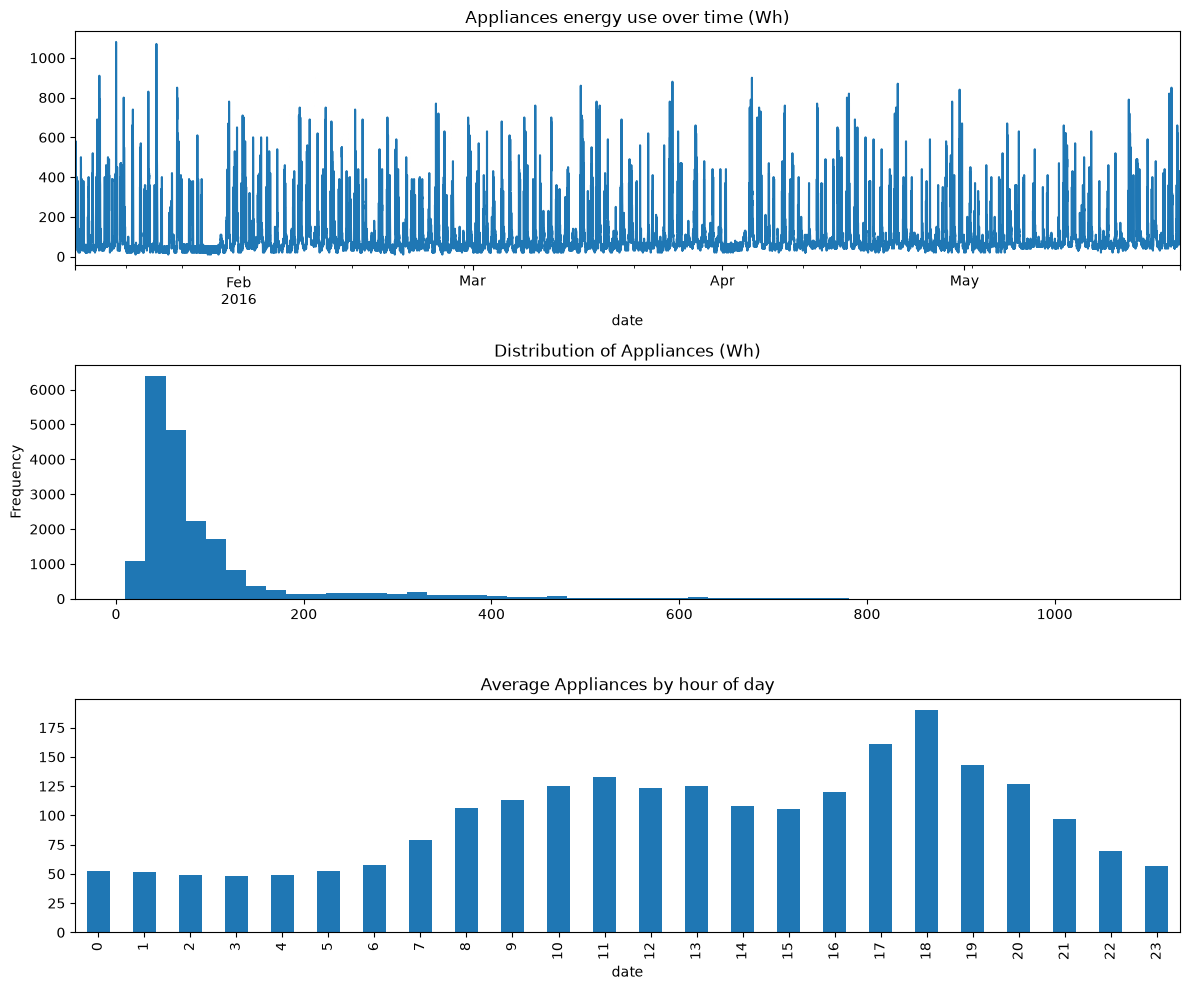

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

df["Appliances"].plot(ax=axes[0], title="Appliances energy use over time (Wh)")
df["Appliances"].plot(kind="hist", bins=50, ax=axes[1], title="Distribution of Appliances (Wh)")
df.groupby(df.index.hour)["Appliances"].mean().plot(
    kind="bar", ax=axes[2], title="Average Appliances by hour of day"
)

plt.tight_layout()
plt.show()

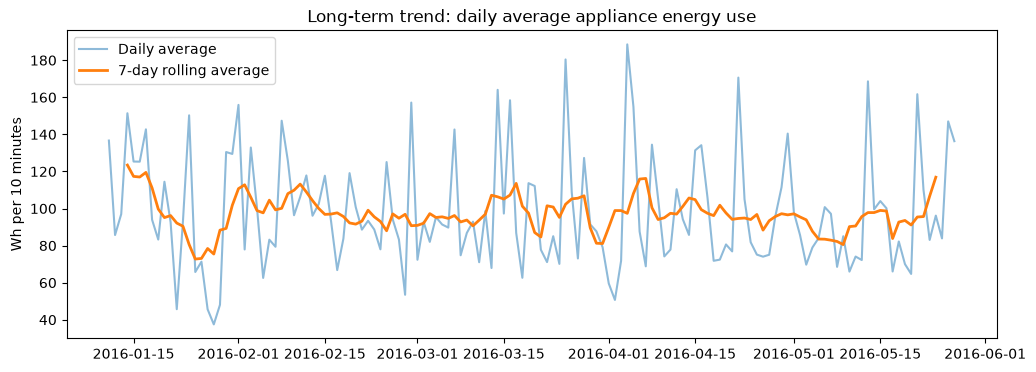

In [4]:
daily = df["Appliances"].resample("D").mean()
plt.figure(figsize=(12, 4))
plt.plot(daily.index, daily, alpha=0.5, label="Daily average")
plt.plot(daily.index, daily.rolling(7, center=True).mean(), linewidth=2, label="7-day rolling average")
plt.title("Long-term trend: daily average appliance energy use")
plt.ylabel("Wh per 10 minutes")
plt.legend()
plt.show()

**Findings**

- Consumption is a low baseline (about 50 Wh) with frequent short spikes of several hundred Wh.
- **Strong daily cycle:** about 50 Wh overnight, rising from 7:00 and peaking at 17:00-18:00 at almost four times the night level.
- **No long-term trend:** the 7-day average stays between about 80 and 120 Wh. With only 4.5 months of data,
  a month feature is left out, since the test period falls in a month the model barely sees in training.

IQR upper bound: 175 Wh
Rows above it: 2138 (10.8%)


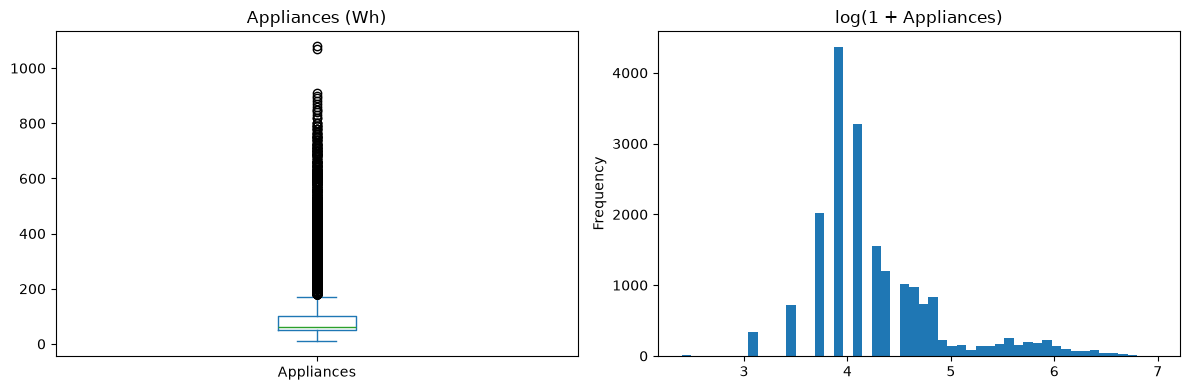

In [5]:
import numpy as np

q1, q3 = df["Appliances"].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
n_out = (df["Appliances"] > upper).sum()
print(f"IQR upper bound: {upper:.0f} Wh")
print(f"Rows above it: {n_out} ({n_out / len(df):.1%})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Appliances"].plot(kind="box", ax=axes[0], title="Appliances (Wh)")
np.log1p(df["Appliances"]).plot(kind="hist", bins=50, ax=axes[1], title="log(1 + Appliances)")
plt.tight_layout()
plt.show()

**Outliers:** 2,138 readings (10.8%) are above the IQR upper bound of 175 Wh. That is too many to be errors;
they are real high-use periods the model must predict, so **they are kept**. The target is modelled as
`log(1 + Appliances)` instead, which is far less skewed; all metrics are converted back to Wh.

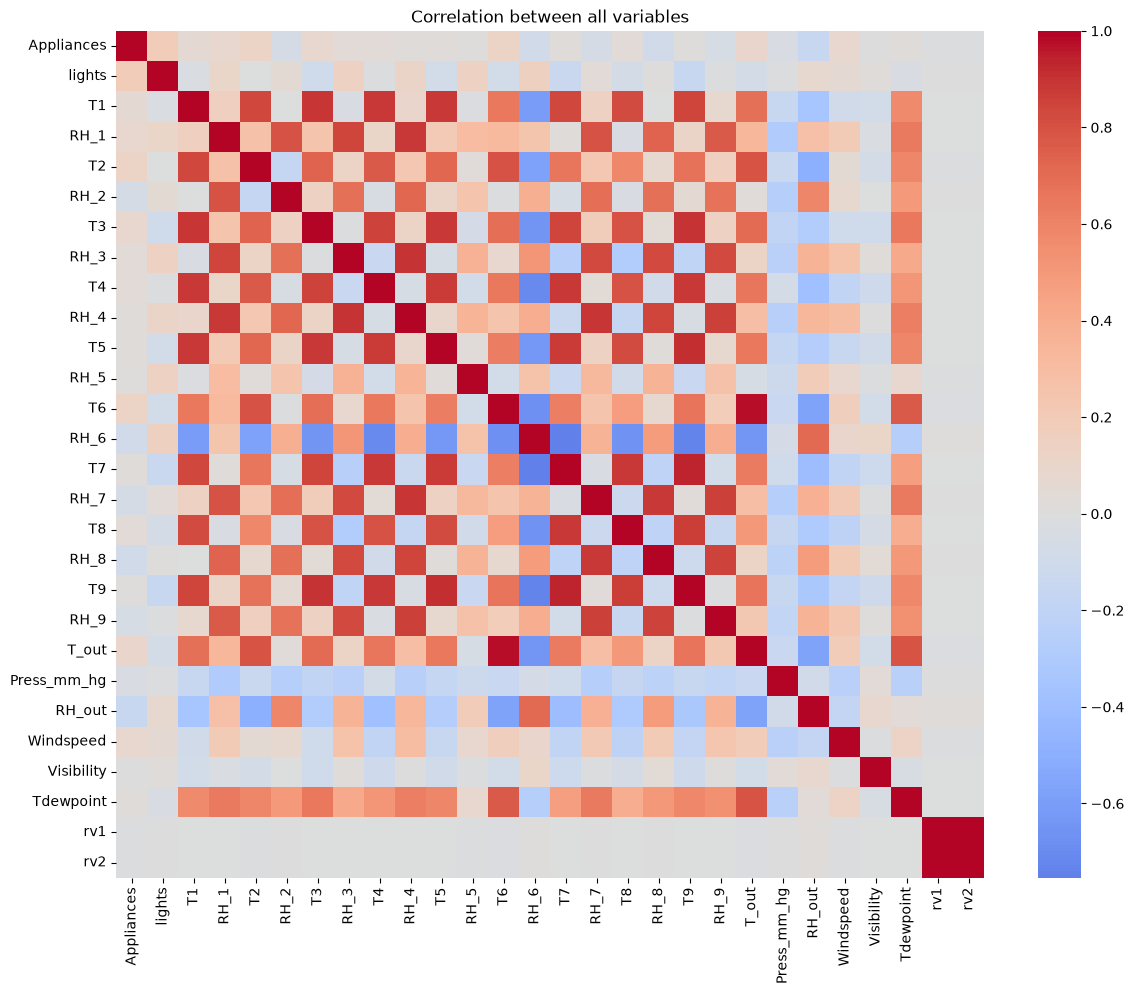

Appliances     1.000000
lights         0.197278
T2             0.120073
T6             0.117638
T_out          0.099155
Windspeed      0.087122
RH_1           0.086031
T3             0.085060
T1             0.055447
T4             0.040281
T8             0.039572
RH_3           0.036292
T7             0.025801
T5             0.019760
RH_4           0.016965
Tdewpoint      0.015353
T9             0.010010
RH_5           0.006955
Visibility     0.000230
rv1           -0.011145
rv2           -0.011145
Press_mm_hg   -0.034885
RH_9          -0.051462
RH_7          -0.055642
RH_2          -0.060465
RH_6          -0.083178
RH_8          -0.094039
RH_out        -0.152282
Name: Appliances, dtype: float64


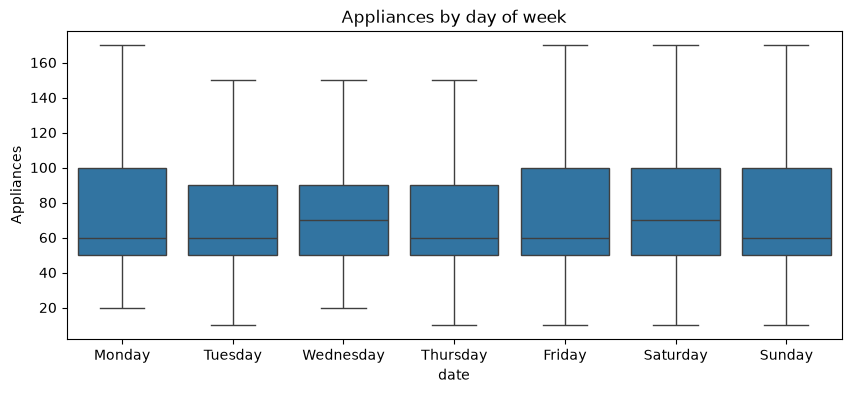

In [6]:
import seaborn as sns

plt.figure(figsize=(14, 11))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation between all variables")
plt.show()

print(df.corr()["Appliances"].sort_values(ascending=False))

days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plt.figure(figsize=(10, 4))
sns.boxplot(x=df.index.day_name(), y=df["Appliances"], order=days, showfliers=False)
plt.title("Appliances by day of week")
plt.show()

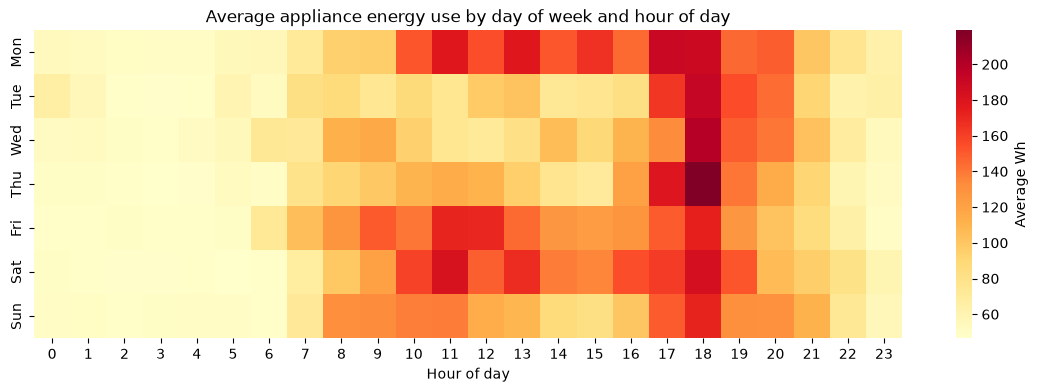

In [7]:
weekly = df.groupby([df.index.dayofweek, df.index.hour])["Appliances"].mean().unstack()
weekly.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
plt.figure(figsize=(14, 4))
sns.heatmap(weekly, cmap="YlOrRd", cbar_kws={"label": "Average Wh"})
plt.title("Average appliance energy use by day of week and hour of day")
plt.xlabel("Hour of day")
plt.ylabel("")
plt.show()

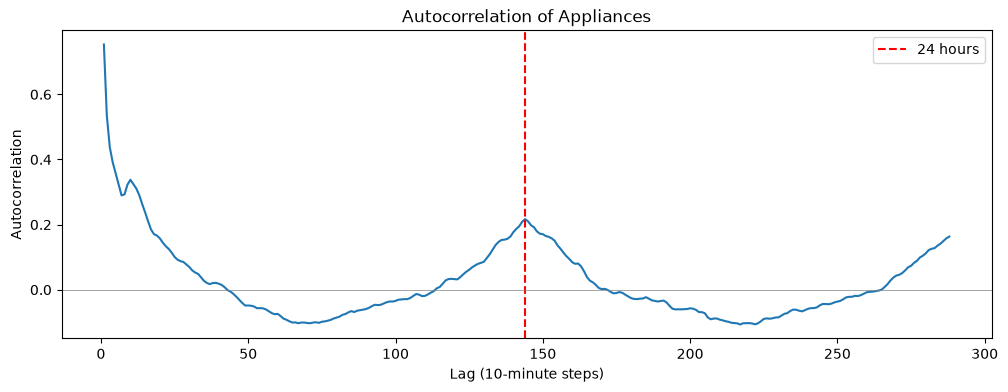

lag   1 (  10 min): 0.753
lag   2 (  20 min): 0.534
lag   3 (  30 min): 0.438
lag   6 (  60 min): 0.324
lag  12 ( 120 min): 0.311
lag  18 ( 180 min): 0.171
lag  36 ( 360 min): 0.021
lag  72 ( 720 min): -0.101
lag 144 (1440 min): 0.217


In [8]:
lags = range(1, 289)   # up to 48 hours (288 steps of 10 minutes)
acf = [df["Appliances"].autocorr(lag=k) for k in lags]

plt.figure(figsize=(12, 4))
plt.plot(lags, acf)
plt.axvline(144, color="red", linestyle="--", label="24 hours")
plt.axhline(0, color="grey", linewidth=0.5)
plt.xlabel("Lag (10-minute steps)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of Appliances")
plt.legend()
plt.show()

for k in [1, 2, 3, 6, 12, 18, 36, 72, 144]:
    print(f"lag {k:>3} ({k * 10:>4} min): {df['Appliances'].autocorr(lag=k):.3f}")

**Lag selection from autocorrelation**

| Lag | Autocorrelation | Decision |
|---|---|---|
| 10, 20, 30 min | 0.75, 0.53, 0.44 | used |
| 1 h, 2 h | 0.32, 0.31 | used |
| 6 h, 12 h | 0.02, -0.10 | not used |
| 24 h | 0.22 | used (daily cycle) |

## 3. Feature engineering

Built in `src/feature_engineering.py`. Every sensor and consumption feature is **shifted at least one step**,
so features for time t use only information from before t (no data leakage).

| Group | Features |
|---|---|
| Lags | 10, 20, 30, 60, 120 min and 24 h ago, plus the latest change |
| Rolling | mean, standard deviation, maximum over the past 1 h and 3 h |
| Time | seconds since midnight, hour as sine/cosine, day of week, weekend flag |
| Interaction | indoor-outdoor temperature gap, temperature × humidity, kitchen humidity excess, weekend × hour |
| Domain | Belgian public holidays |

In [9]:
import sys
sys.path.append("../src")
from feature_engineering import build_features

features = build_features(df)
print(features.shape)
print(features.columns.tolist())

features.to_csv("../data/processed/features.csv")

(19591, 52)
['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'app_lag_1', 'app_lag_2', 'app_lag_3', 'app_lag_6', 'app_lag_12', 'app_lag_144', 'app_diff_1', 'app_roll_mean_1h', 'app_roll_std_1h', 'app_roll_max_1h', 'app_roll_mean_3h', 'app_roll_std_3h', 'app_roll_max_3h', 'indoor_temp_mean', 'indoor_rh_mean', 'temp_gap_in_out', 'temp_x_rh', 'kitchen_rh_excess', 'NSM', 'hour_sin', 'hour_cos', 'day_of_week', 'is_weekend', 'is_holiday', 'weekend_hour_sin', 'weekend_hour_cos']


Result: 19,591 rows × 51 features (the first 24 hours are dropped for lack of history).

## 4. Chronological split and scaling

- **Time-ordered split:** 70% train, 10% validation (early stopping, model selection), 20% test.
- **Standardisation**, fitted on training rows only. Min-max scaling was avoided because the spikes would
  squash most values into a narrow range.

In [10]:
from data_preprocessing import chronological_split, split_xy, scale_features, to_wh

train, val, test = chronological_split(features)
for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:<5} {len(part):>6} rows   {part.index.min()}  to  {part.index.max()}")

X_train, y_train = split_xy(train)
X_val, y_val = split_xy(val)
X_test, y_test = split_xy(test)
X_train_s, X_val_s, X_test_s, scaler = scale_features(X_train, X_val, X_test)
print("Features:", X_train_s.shape[1])

train  13713 rows   2016-01-12 17:00:00  to  2016-04-16 22:20:00
val     1959 rows   2016-04-16 22:30:00  to  2016-04-30 12:50:00
test    3919 rows   2016-04-30 13:00:00  to  2016-05-27 18:00:00
Features: 51


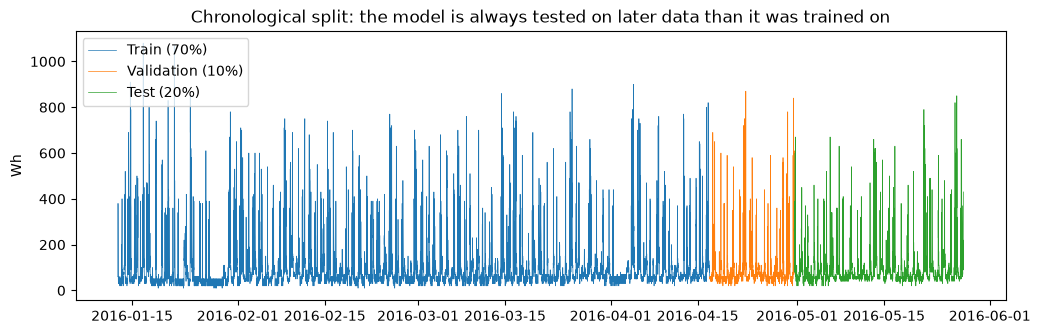

In [11]:
plt.figure(figsize=(12, 3.5))
for part, name, color in [(train, "Train (70%)", "C0"), (val, "Validation (10%)", "C1"), (test, "Test (20%)", "C2")]:
    plt.plot(part.index, part["Appliances"], color=color, linewidth=0.5, label=name)
plt.title("Chronological split: the model is always tested on later data than it was trained on")
plt.ylabel("Wh")
plt.legend(loc="upper left")
plt.show()

## 5. Baseline models

Naive (repeat the last reading), Linear Regression and Random Forest set the bar for the deep learning models.

                      MAE   RMSE  MAPE %    R2
model                                         
Naive (last value)  26.05  65.19   21.86  0.45
Linear Regression   27.26  66.49   22.12  0.43
Random Forest       26.51  58.30   23.19  0.56


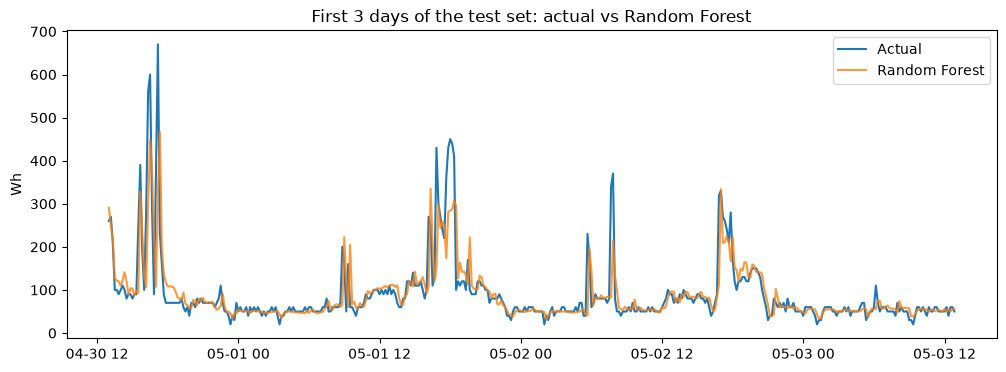

In [12]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate(name, actual_wh, predicted_wh):
    """Return MAE, RMSE, MAPE and R2 for one model, all on the original Wh scale."""
    return {
        "model": name,
        "MAE": mean_absolute_error(actual_wh, predicted_wh),
        "RMSE": np.sqrt(mean_squared_error(actual_wh, predicted_wh)),
        "MAPE %": np.mean(np.abs((actual_wh - predicted_wh) / actual_wh)) * 100,
        "R2": r2_score(actual_wh, predicted_wh),
    }


actual = test["Appliances"].values
results = []

# Naive baseline: predict that the next reading equals the last one.
results.append(evaluate("Naive (last value)", actual, X_test["app_lag_1"].values))

linear = LinearRegression().fit(X_train_s, y_train)
results.append(evaluate("Linear Regression", actual, to_wh(linear.predict(X_test_s))))

forest = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=42)
forest.fit(X_train_s, y_train)
forest_pred = to_wh(forest.predict(X_test_s))
results.append(evaluate("Random Forest", actual, forest_pred))

baseline_results = pd.DataFrame(results).set_index("model").round(2)
print(baseline_results)

plt.figure(figsize=(12, 4))
plt.plot(test.index[:432], actual[:432], label="Actual")
plt.plot(test.index[:432], forest_pred[:432], label="Random Forest", alpha=0.8)
plt.title("First 3 days of the test set: actual vs Random Forest")
plt.ylabel("Wh")
plt.legend()
plt.show()

**Findings:** neither model beats the naive baseline on MAE (26.05); the Random Forest improves RMSE by about 10%
(58.30 vs 65.19). The plot shows it mostly repeats the last reading, one step late.
**Target for the deep learning model: MAE below 26 and RMSE below 58.**

## 6. Feature selection

Random Forest importance ranks the 51 features; subsets are then compared on the **validation** set.

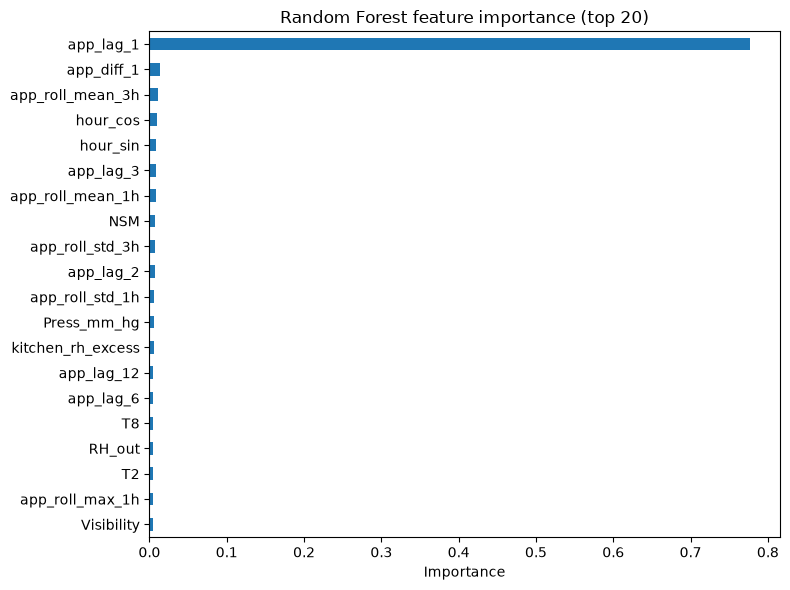

app_lag_1            0.7768
app_diff_1           0.0134
app_roll_mean_3h     0.0105
hour_cos             0.0103
hour_sin             0.0085
app_lag_3            0.0084
app_roll_mean_1h     0.0081
NSM                  0.0077
app_roll_std_3h      0.0074
app_lag_2            0.0073
app_roll_std_1h      0.0059
Press_mm_hg          0.0059
kitchen_rh_excess    0.0058
app_lag_12           0.0050
app_lag_6            0.0050
T8                   0.0049
RH_out               0.0048
T2                   0.0046
app_roll_max_1h      0.0046
Visibility           0.0045
T4                   0.0044
app_lag_144          0.0043
app_roll_max_3h      0.0043
RH_5                 0.0042
RH_2                 0.0042
RH_6                 0.0040
indoor_temp_mean     0.0036
RH_1                 0.0036
Windspeed            0.0036
RH_9                 0.0035
Tdewpoint            0.0035
T3                   0.0034
temp_gap_in_out      0.0033
RH_8                 0.0033
T9                   0.0032
T7                  

In [13]:
importance = pd.Series(forest.feature_importances_, index=X_train_s.columns).sort_values(ascending=False)

importance.head(20).sort_values().plot(
    kind="barh", figsize=(8, 6), title="Random Forest feature importance (top 20)"
)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importance.round(4).to_string())

In [14]:
val_actual = val["Appliances"].values
rows = []
for k in [1, 5, 10, 15, 20, 30, 51]:
    cols = importance.index[:k]
    model = RandomForestRegressor(n_estimators=100, min_samples_leaf=5, n_jobs=-1, random_state=42)
    model.fit(X_train_s[cols], y_train)
    pred = to_wh(model.predict(X_val_s[cols]))
    rows.append({
        "features": k,
        "val MAE": mean_absolute_error(val_actual, pred),
        "val RMSE": np.sqrt(mean_squared_error(val_actual, pred)),
    })
print(pd.DataFrame(rows).set_index("features").round(2))

selected_features = list(importance.index[:10])
print(selected_features)

          val MAE  val RMSE
features                   
1           25.03     64.11
5           23.98     57.95
10          23.37     58.11
15          23.64     59.08
20          23.97     59.62
30          24.52     59.49
51          24.10     59.43
['app_lag_1', 'app_diff_1', 'app_roll_mean_3h', 'hour_cos', 'hour_sin', 'app_lag_3', 'app_roll_mean_1h', 'NSM', 'app_roll_std_3h', 'app_lag_2']


**Findings:** `app_lag_1` alone carries about 78% of the importance. The **top 10 features** give the lowest
validation MAE (23.37); adding all 51 makes it slightly worse (24.10). All ten are past consumption or time of day.

## 7. LSTM model

Input: the last 2 hours (12 steps) of the 10 selected features, covering the 1-2 hour autocorrelation plateau.

`LSTM (64, tanh) → Dropout (0.2) → Dense (32, ReLU) → Dense (1, linear)`, 21,313 parameters.
Adam (learning rate 0.001), MSE loss, early stopping (patience 10, best weights restored), and learning-rate
halving when validation loss stalls. The log target is standardised with training-set statistics.

In [15]:
import importlib
import tensorflow as tf
import data_preprocessing
importlib.reload(data_preprocessing)  # picks up the updated file without restarting
from data_preprocessing import make_sequences
from model import build_lstm, default_callbacks

WINDOW = 12  # each sample sees the last 2 hours (12 x 10 minutes)

# Standardise the log target using training statistics only.
y_mean, y_std = y_train.mean(), y_train.std()

(X_train_seq, y_train_seq), (X_val_seq, y_val_seq), (X_test_seq, y_test_seq) = make_sequences(
    [X_train_s[selected_features], X_val_s[selected_features], X_test_s[selected_features]],
    [(y_train - y_mean) / y_std, (y_val - y_mean) / y_std, (y_test - y_mean) / y_std],
    WINDOW,
)
print("Train:", X_train_seq.shape, " Val:", X_val_seq.shape, " Test:", X_test_seq.shape)

Train: (13702, 12, 10)  Val: (1959, 12, 10)  Test: (3919, 12, 10)


In [16]:
tf.keras.utils.set_random_seed(42)

lstm = build_lstm(WINDOW, len(selected_features))
lstm.summary()

history = lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=150,
    batch_size=64,
    callbacks=default_callbacks(),
    verbose=2,
)

Model: "lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,313 (83.25 KB)

 Trainable params: 21,313 (83.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
215/215 - 3s - 14ms/step - loss: 0.4098 - mae: 0.4408 - val_loss: 0.2453 - val_mae: 0.3328 - learning_rate: 0.0010
Epoch 2/150
215/215 - 1s - 6ms/step - loss: 0.3142 - mae: 0.3757 - val_loss: 0.2210 - val_mae: 0.3146 - learning_rate: 0.0010
Epoch 3/150
215/215 - 1s - 5ms/step - loss: 0.2939 - mae: 0.3618 - val_loss: 0.2139 - val_mae: 0.3084 - learning_rate: 0.0010
Epoch 4/150
215/215 - 1s - 6ms/step - loss: 0.2879 - mae: 0.3570 - val_loss: 0.2122 - val_mae: 0.3083 - learning_rate: 0.0010
Epoch 5/150
215/215 - 1s - 5ms/step - loss: 0.2860 - mae: 0.3550 - val_loss: 0.2108 - val_mae: 0.3045 - learning_rate: 0.0010
Epoch 6/150
215/215 - 1s - 6ms/step - loss: 0.2827 - mae: 0.3539 - val_loss: 0.2097 - val_mae: 0.3042 - learning_rate: 0.0010
Epoch 7/150
215/215 - 1s - 5ms/step - loss: 0.2774 - mae: 0.3502 - val_loss: 0.2078 - val_mae: 0.3009 - learning_rate: 0.0010
Epoch 8/150
215/215 - 1s - 5ms/step - loss: 0.2785 - mae: 0.3503 - val_loss: 0.2085 - val_mae: 0.3052 - learning_rate

                      MAE   RMSE  MAPE %    R2
model                                         
Naive (last value)  26.05  65.19   21.86  0.45
Linear Regression   27.26  66.49   22.12  0.43
Random Forest       26.51  58.30   23.19  0.56
LSTM                23.41  56.78   19.38  0.58


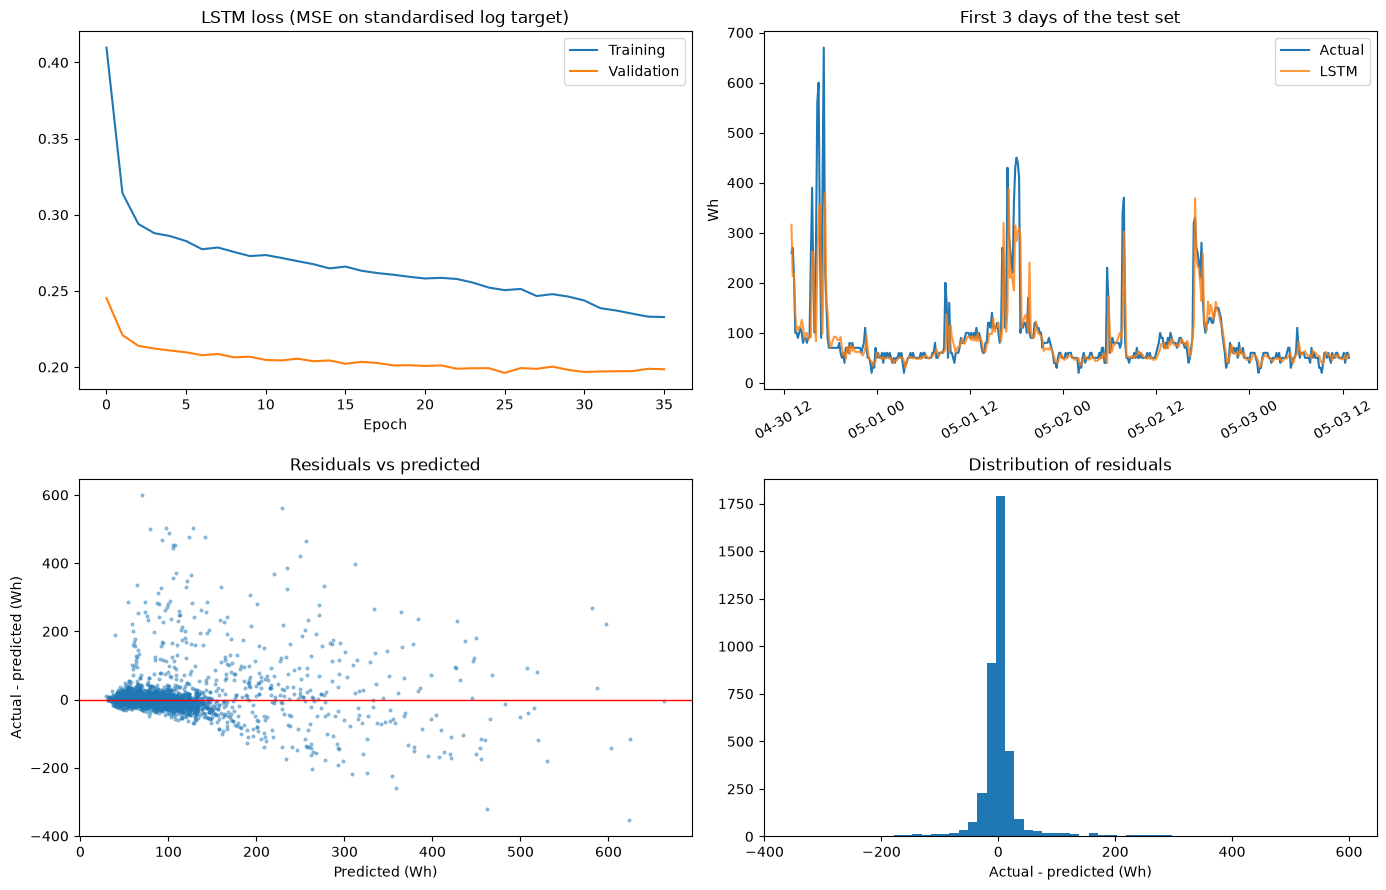

In [17]:
lstm_pred = to_wh(lstm.predict(X_test_seq, verbose=0).ravel() * y_std + y_mean)

lstm_row = pd.DataFrame([evaluate("LSTM", actual, lstm_pred)]).set_index("model").round(2)
comparison = pd.concat([baseline_results, lstm_row])
print(comparison)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(history.history["loss"], label="Training")
axes[0, 0].plot(history.history["val_loss"], label="Validation")
axes[0, 0].set_title("LSTM loss (MSE on standardised log target)")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()

axes[0, 1].plot(test.index[:432], actual[:432], label="Actual")
axes[0, 1].plot(test.index[:432], lstm_pred[:432], label="LSTM", alpha=0.8)
axes[0, 1].set_title("First 3 days of the test set")
axes[0, 1].set_ylabel("Wh")
axes[0, 1].tick_params(axis="x", rotation=30)
axes[0, 1].legend()

residuals = actual - lstm_pred
axes[1, 0].scatter(lstm_pred, residuals, s=4, alpha=0.4)
axes[1, 0].axhline(0, color="red", linewidth=1)
axes[1, 0].set_title("Residuals vs predicted")
axes[1, 0].set_xlabel("Predicted (Wh)")
axes[1, 0].set_ylabel("Actual - predicted (Wh)")

axes[1, 1].hist(residuals, bins=60)
axes[1, 1].set_title("Distribution of residuals")
axes[1, 1].set_xlabel("Actual - predicted (Wh)")

plt.tight_layout()
plt.show()

**Findings:** the LSTM reaches **MAE 23.41, RMSE 56.78**, the first model to beat the naive baseline on MAE
(about 10% lower). The loss curves flatten without validation loss rising, so it is not overfitting.
Residuals are small near the baseline and large around spikes, which it underestimates.

**Challenge solved:** with the plain log target the same LSTM only reached MAE 26.8; standardising the target
brought it to 23.4.

## 8. Architecture comparison

LSTM, GRU, CNN-LSTM and stacked LSTM, each trained with **3 seeds** so real differences can be told apart
from luck. Scored on validation only.

In [18]:
import time
import importlib
import model as model_module
importlib.reload(model_module)  # picks up the updated model.py
from model import build_lstm, build_gru, build_cnn_lstm, build_stacked_lstm, default_callbacks

builders = {
    "LSTM": build_lstm,
    "GRU": build_gru,
    "CNN-LSTM": build_cnn_lstm,
    "Stacked LSTM": build_stacked_lstm,
}
SEEDS = [42, 7, 123]  # train each model 3 times to separate real differences from luck

val_actual = val["Appliances"].values
runs = []
for name, build in builders.items():
    for seed in SEEDS:
        tf.keras.utils.set_random_seed(seed)
        net = build(WINDOW, len(selected_features))
        start = time.time()
        fit = net.fit(
            X_train_seq, y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=150, batch_size=64,
            callbacks=default_callbacks(), verbose=0,
        )
        val_pred = to_wh(net.predict(X_val_seq, verbose=0).ravel() * y_std + y_mean)
        runs.append({
            "model": name,
            "seed": seed,
            "parameters": net.count_params(),
            "epochs": len(fit.history["loss"]),
            "seconds": time.time() - start,
            "val MAE": mean_absolute_error(val_actual, val_pred),
            "val RMSE": np.sqrt(mean_squared_error(val_actual, val_pred)),
        })
        print(f"{name:<13} seed {seed:>3}:  val MAE {runs[-1]['val MAE']:.2f}   val RMSE {runs[-1]['val RMSE']:.2f}")

runs = pd.DataFrame(runs)
architecture_results = runs.groupby("model", sort=False).agg(
    parameters=("parameters", "first"),
    avg_epochs=("epochs", "mean"),
    avg_seconds=("seconds", "mean"),
    val_MAE=("val MAE", "mean"),
    val_MAE_std=("val MAE", "std"),
    val_RMSE=("val RMSE", "mean"),
).round(2)
display(architecture_results)

LSTM          seed  42:  val MAE 23.55   val RMSE 58.68
LSTM          seed   7:  val MAE 23.91   val RMSE 60.81
LSTM          seed 123:  val MAE 23.39   val RMSE 59.09
GRU           seed  42:  val MAE 23.94   val RMSE 59.88
GRU           seed   7:  val MAE 24.61   val RMSE 59.65
GRU           seed 123:  val MAE 23.84   val RMSE 60.20
CNN-LSTM      seed  42:  val MAE 22.96   val RMSE 58.69
CNN-LSTM      seed   7:  val MAE 23.22   val RMSE 57.90
CNN-LSTM      seed 123:  val MAE 22.98   val RMSE 58.39
Stacked LSTM  seed  42:  val MAE 23.66   val RMSE 60.06
Stacked LSTM  seed   7:  val MAE 23.67   val RMSE 58.81
Stacked LSTM  seed 123:  val MAE 23.13   val RMSE 59.40


,parameters,avg_epochs,avg_seconds,val_MAE,val_MAE_std,val_RMSE
model,,,,,,
LSTM,21313,40.00,46.08,23.61,0.27,59.53
GRU,16705,42.67,58.85,24.13,0.42,59.91
CNN-LSTM,27937,42.00,59.82,23.05,0.14,58.33
Stacked LSTM,32705,33.33,112.44,23.48,0.31,59.42


**Findings (mean of 3 seeds):** CNN-LSTM is best (validation MAE 23.05, RMSE 58.33) and the most consistent
(spread 0.14), ahead of the stacked LSTM (23.48), LSTM (23.61) and GRU (24.13). Its convolution picks up
short local patterns before the LSTM models how they develop. The stacked LSTM's extra parameters bring no gain.

## 9. Hyperparameter tuning

Random search over 20 of 8,748 possible configurations (window, filters, kernel, units, dropout, learning rate,
batch size); the top 3 are then re-trained with two more seeds.

In [19]:
import importlib
import train as train_module
importlib.reload(train_module)
from train import SEARCH_SPACE, DEFAULT_CONFIG, sample_configs, run_trial

X_parts = [X_train_s[selected_features], X_val_s[selected_features], X_test_s[selected_features]]
y_parts = [y_train, y_val, y_test]

N_TRIALS = 20
configs = sample_configs(SEARCH_SPACE, N_TRIALS, seed=0)

search_rows = []
for i, config in enumerate(configs, start=1):
    metrics, _, _ = run_trial(config, X_parts, y_parts, y_mean, y_std, seed=42)
    search_rows.append(metrics)
    print(f"Trial {i:>2}/{N_TRIALS}: val MAE {metrics['val MAE']:.2f}  val RMSE {metrics['val RMSE']:.2f}  ({metrics['seconds']}s)  {config}")


search_results = pd.DataFrame(search_rows).sort_values("val MAE").round({"val MAE": 2, "val RMSE": 2})
search_results.to_csv("../reports/random_search_results.csv", index=False)
print(search_results.head(10).to_string())

Trial  1/20: val MAE 24.02  val RMSE 60.63  (42s)  {'window': 12, 'filters': 32, 'kernel_size': 2, 'units': 64, 'dense_units': 64, 'dropout': 0.4, 'learning_rate': 0.001, 'batch_size': 64}
Trial  2/20: val MAE 23.52  val RMSE 59.94  (71s)  {'window': 12, 'filters': 32, 'kernel_size': 5, 'units': 32, 'dense_units': 64, 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 32}
Trial  3/20: val MAE 23.87  val RMSE 59.58  (62s)  {'window': 6, 'filters': 64, 'kernel_size': 3, 'units': 128, 'dense_units': 64, 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 32}
Trial  4/20: val MAE 23.28  val RMSE 58.40  (72s)  {'window': 24, 'filters': 16, 'kernel_size': 5, 'units': 64, 'dense_units': 32, 'dropout': 0.1, 'learning_rate': 0.001, 'batch_size': 64}
Trial  5/20: val MAE 25.67  val RMSE 66.71  (17s)  {'window': 12, 'filters': 64, 'kernel_size': 5, 'units': 32, 'dense_units': 64, 'dropout': 0.4, 'learning_rate': 0.001, 'batch_size': 128}
Trial  6/20: val MAE 24.48  val RMSE 62.32  (28s)  {'w

In [20]:
HYPERPARAMETERS = list(SEARCH_SPACE)
top_configs = search_results.head(3)[HYPERPARAMETERS].to_dict("records")

recheck_rows = []
for rank, config in enumerate(top_configs, start=1):
    scores = [float(search_results.iloc[rank - 1]["val MAE"])]  # seed 42, from the search
    for seed in [7, 123]:
        metrics, _, _ = run_trial(config, X_parts, y_parts, y_mean, y_std, seed=seed)
        scores.append(metrics["val MAE"])
    recheck_rows.append({
        "rank": rank,
        **config,
        "seed 42": scores[0],
        "seed 7": scores[1],
        "seed 123": scores[2],
        "mean val MAE": np.mean(scores),
    })
    print(f"Rank {rank}: val MAE by seed {[round(s, 2) for s in scores]}  ->  mean {np.mean(scores):.2f}")

recheck = pd.DataFrame(recheck_rows).set_index("rank").round({"seed 42": 2, "seed 7": 2, "seed 123": 2, "mean val MAE": 2})
display(recheck)

Rank 1: val MAE by seed [22.94, 24.7, 23.64]  ->  mean 23.76
Rank 2: val MAE by seed [23.18, 24.05, 23.43]  ->  mean 23.55
Rank 3: val MAE by seed [23.28, 25.09, 23.69]  ->  mean 24.02


,window,filters,kernel_size,units,dense_units,dropout,learning_rate,batch_size,seed 42,seed 7,seed 123,mean val MAE
rank,,,,,,,,,,,,
1,24,16,5,64,32,0.2,0.003,64,22.94,24.70,23.64,23.76
2,24,64,5,64,32,0.1,0.003,64,23.18,24.05,23.43,23.55
3,24,16,5,64,32,0.1,0.001,64,23.28,25.09,23.69,24.02


**Findings:** the best single run scored 22.94, but re-trained across seeds the top three averaged
**23.76, 23.55 and 24.02**, worse than the untuned CNN-LSTM (23.05) and less stable. Their single-run scores
were partly luck, so **the default settings are kept**.

## 10. Dropout experiment

Dropout 0.0 to 0.4 on the CNN-LSTM, 3 seeds each.

In [21]:
DROPOUT_RATES = [0.0, 0.1, 0.2, 0.3, 0.4]
SEEDS = [42, 7, 123]

dropout_rows = []
dropout_models = {}
for rate in DROPOUT_RATES:
    for seed in SEEDS:
        config = {**DEFAULT_CONFIG, "dropout": rate}
        metrics, net, sequences = run_trial(config, X_parts, y_parts, y_mean, y_std, seed=seed)
        dropout_rows.append(metrics)
        dropout_models[(rate, seed)] = net
        print(f"dropout {rate}  seed {seed:>3}:  val MAE {metrics['val MAE']:.2f}   val RMSE {metrics['val RMSE']:.2f}")

dropout_results = pd.DataFrame(dropout_rows).groupby("dropout").agg(
    val_MAE=("val MAE", "mean"),
    val_MAE_std=("val MAE", "std"),
    val_RMSE=("val RMSE", "mean"),
    avg_epochs=("epochs", "mean"),
).round(2)
display(dropout_results)

dropout 0.0  seed  42:  val MAE 24.27   val RMSE 59.93
dropout 0.0  seed   7:  val MAE 24.00   val RMSE 58.46
dropout 0.0  seed 123:  val MAE 24.20   val RMSE 59.17
dropout 0.1  seed  42:  val MAE 23.65   val RMSE 59.81
dropout 0.1  seed   7:  val MAE 23.46   val RMSE 58.55
dropout 0.1  seed 123:  val MAE 23.22   val RMSE 58.41
dropout 0.2  seed  42:  val MAE 22.96   val RMSE 58.69
dropout 0.2  seed   7:  val MAE 23.22   val RMSE 57.90
dropout 0.2  seed 123:  val MAE 22.98   val RMSE 58.39
dropout 0.3  seed  42:  val MAE 22.95   val RMSE 58.07
dropout 0.3  seed   7:  val MAE 23.13   val RMSE 57.95
dropout 0.3  seed 123:  val MAE 22.92   val RMSE 58.66
dropout 0.4  seed  42:  val MAE 23.28   val RMSE 59.09
dropout 0.4  seed   7:  val MAE 23.35   val RMSE 60.05
dropout 0.4  seed 123:  val MAE 23.64   val RMSE 59.38


,val_MAE,val_MAE_std,val_RMSE,avg_epochs
dropout,,,,
0.0,24.16,0.14,59.19,37.00
0.1,23.44,0.21,58.92,47.00
0.2,23.05,0.14,58.33,42.00
0.3,23.00,0.11,58.23,46.67
0.4,23.42,0.19,59.51,65.33


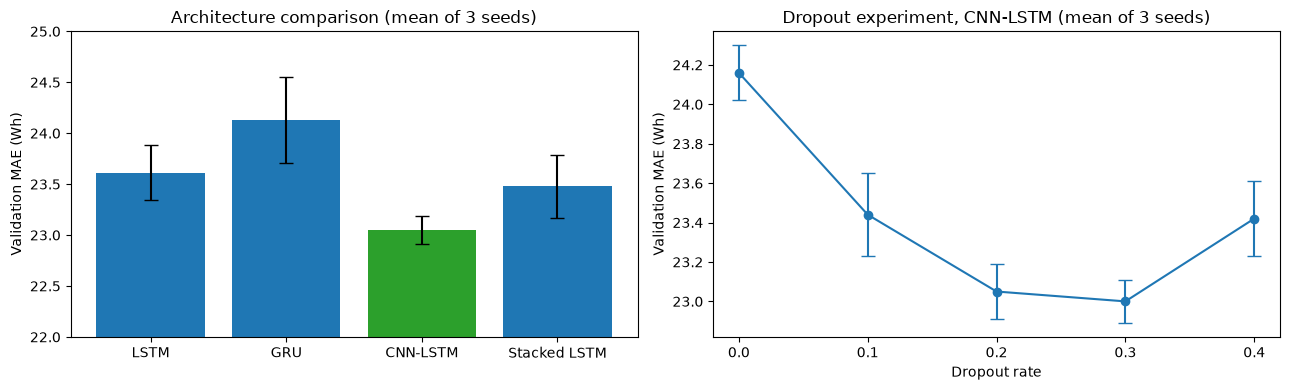

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(architecture_results.index, architecture_results["val_MAE"],
            yerr=architecture_results["val_MAE_std"], capsize=5, color=["C0", "C0", "C2", "C0"])
axes[0].set_ylim(22, 25)
axes[0].set_title("Architecture comparison (mean of 3 seeds)")
axes[0].set_ylabel("Validation MAE (Wh)")

axes[1].errorbar(dropout_results.index, dropout_results["val_MAE"], yerr=dropout_results["val_MAE_std"],
                 marker="o", capsize=5)
axes[1].set_title("Dropout experiment, CNN-LSTM (mean of 3 seeds)")
axes[1].set_xlabel("Dropout rate")
axes[1].set_ylabel("Validation MAE (Wh)")
axes[1].set_xticks(dropout_results.index)
plt.tight_layout()
plt.show()

**Findings:** no dropout is clearly worst (24.16); 0.2 and 0.3 are effectively tied (23.05, 23.00), and
**0.3 is chosen**.

## 11. Final model: seed ensemble

Three CNN-LSTMs (dropout 0.3) trained with different seeds, with their predictions averaged. The test set is
used here for the first time since the baselines.

Chosen dropout: 0.3
Validation MAE: single model 23.00  ->  3-seed ensemble 22.55


,MAE,RMSE,MAPE %,R2
model,,,,
Naive (last value),26.05,65.19,21.86,0.45
Linear Regression,27.26,66.49,22.12,0.43
Random Forest,26.51,58.30,23.19,0.56
LSTM,23.41,56.78,19.38,0.58
CNN-LSTM (before optimisation),23.70,57.55,19.72,0.57
CNN-LSTM ensemble (after optimisation),22.80,55.71,19.01,0.60


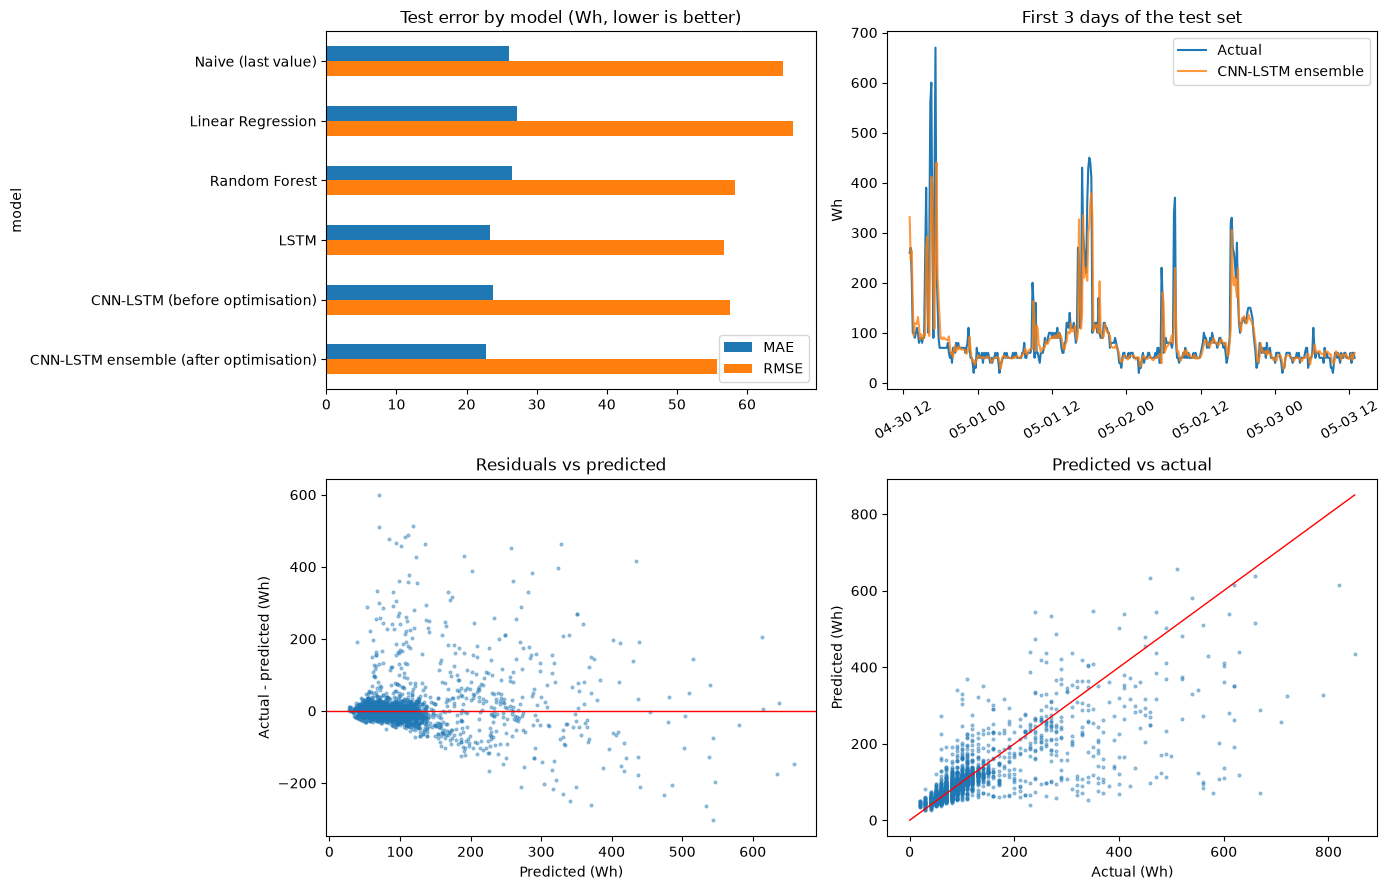

In [23]:
import os

BEST_DROPOUT = dropout_results["val_MAE"].idxmin()
print("Chosen dropout:", BEST_DROPOUT)

# All dropout runs use window 12, so they share the same sequences.
_, (X_val_seq, _), (X_test_seq, _) = sequences
val_actual = val["Appliances"].values


def predict_wh(models, X):
    """Average the Wh predictions of one or more models."""
    preds = [to_wh(m.predict(X, verbose=0).ravel() * y_std + y_mean) for m in models]
    return np.mean(preds, axis=0)


before_model = [dropout_models[(0.2, 42)]]                         # untuned CNN-LSTM, one seed
final_models = [dropout_models[(BEST_DROPOUT, s)] for s in SEEDS]  # best dropout, 3 seeds averaged

# Validation check: does averaging the seeds help?
val_single = np.mean([mean_absolute_error(val_actual, predict_wh([m], X_val_seq)) for m in final_models])
val_ensemble = mean_absolute_error(val_actual, predict_wh(final_models, X_val_seq))
print(f"Validation MAE: single model {val_single:.2f}  ->  3-seed ensemble {val_ensemble:.2f}")

# Test set: used only now, once the model is final.
before_pred = predict_wh(before_model, X_test_seq)
final_pred = predict_wh(final_models, X_test_seq)

final_comparison = pd.concat([
    comparison,
    pd.DataFrame([
        evaluate("CNN-LSTM (before optimisation)", actual, before_pred),
        evaluate("CNN-LSTM ensemble (after optimisation)", actual, final_pred),
    ]).set_index("model").round(2),
])
display(final_comparison)
final_comparison.to_csv("../reports/final_results.csv")

# Save the three ensemble members.
os.makedirs("../models", exist_ok=True)
for seed, m in zip(SEEDS, final_models):
    m.save(f"../models/cnn_lstm_seed{seed}.keras")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

final_comparison[["MAE", "RMSE"]].plot(kind="barh", ax=axes[0, 0])
axes[0, 0].set_title("Test error by model (Wh, lower is better)")
axes[0, 0].invert_yaxis()
axes[0, 0].legend(loc="lower right")

axes[0, 1].plot(test.index[:432], actual[:432], label="Actual")
axes[0, 1].plot(test.index[:432], final_pred[:432], label="CNN-LSTM ensemble", alpha=0.8)
axes[0, 1].set_title("First 3 days of the test set")
axes[0, 1].set_ylabel("Wh")
axes[0, 1].tick_params(axis="x", rotation=30)
axes[0, 1].legend()

final_residuals = actual - final_pred
axes[1, 0].scatter(final_pred, final_residuals, s=4, alpha=0.4)
axes[1, 0].axhline(0, color="red", linewidth=1)
axes[1, 0].set_title("Residuals vs predicted")
axes[1, 0].set_xlabel("Predicted (Wh)")
axes[1, 0].set_ylabel("Actual - predicted (Wh)")

axes[1, 1].scatter(actual, final_pred, s=4, alpha=0.4)
axes[1, 1].plot([0, actual.max()], [0, actual.max()], color="red", linewidth=1)
axes[1, 1].set_title("Predicted vs actual")
axes[1, 1].set_xlabel("Actual (Wh)")
axes[1, 1].set_ylabel("Predicted (Wh)")

plt.tight_layout()
plt.show()

**Final results (test set)**

| Model | MAE | RMSE | MAPE % | R² |
|---|---|---|---|---|
| Naive (last value) | 26.05 | 65.19 | 21.86 | 0.45 |
| Random Forest | 26.51 | 58.30 | 23.19 | 0.56 |
| LSTM | 23.41 | 56.78 | 19.38 | 0.58 |
| CNN-LSTM (before optimisation) | 23.70 | 57.55 | 19.72 | 0.57 |
| **CNN-LSTM ensemble (final)** | **22.80** | **55.71** | **19.01** | **0.60** |

- Against the naive baseline: **MAE -12.5%, RMSE -14.5%**. Before → after optimisation: MAE -3.8%, RMSE -3.2%.
- The ensemble cut validation MAE from 23.00 to 22.55.
- The single CNN-LSTM was slightly worse than the LSTM on test despite being better on validation; differences
  this small are within seed noise, which is why the ensemble is the more reliable result.
- Predictions follow the actual values up to about 200 Wh, then fall below them: large spikes are underestimated.

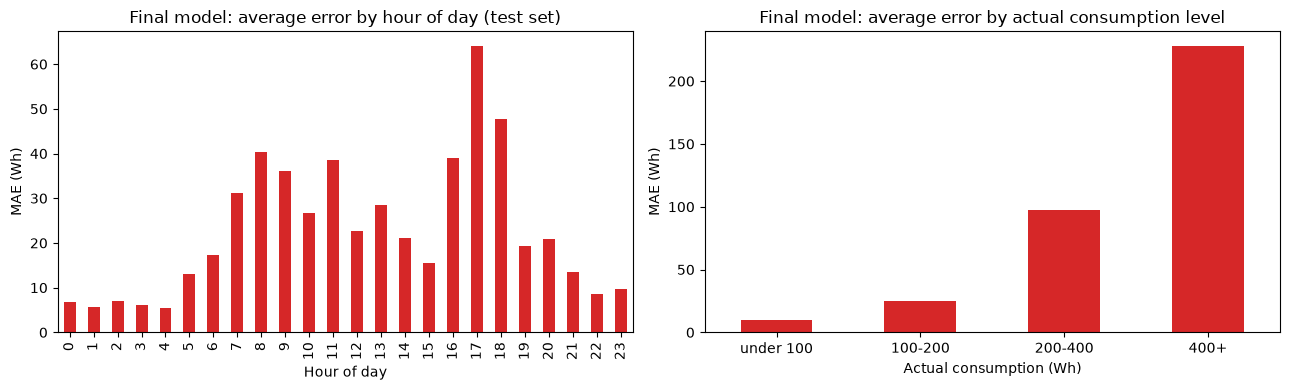

             MAE  share of readings %
actual                               
under 100   10.0                 73.9
100-200     25.1                 18.0
200-400     97.4                  5.8
400+       228.2                  2.3


In [24]:
errors = pd.DataFrame({"abs_error": np.abs(actual - final_pred), "actual": actual}, index=test.index)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
errors.groupby(errors.index.hour)["abs_error"].mean().plot(kind="bar", ax=axes[0], color="C3")
axes[0].set_title("Final model: average error by hour of day (test set)")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("MAE (Wh)")

bins = [0, 100, 200, 400, errors["actual"].max() + 1]
labels = ["under 100", "100-200", "200-400", "400+"]
by_level = errors.groupby(pd.cut(errors["actual"], bins=bins, labels=labels, right=False), observed=False)["abs_error"]
summary = pd.DataFrame({"MAE": by_level.mean(), "share of readings %": by_level.size() / len(errors) * 100})
summary["MAE"].plot(kind="bar", ax=axes[1], color="C3", rot=0)
axes[1].set_title("Final model: average error by actual consumption level")
axes[1].set_xlabel("Actual consumption (Wh)")
axes[1].set_ylabel("MAE (Wh)")
plt.tight_layout()
plt.show()
print(summary.round(1))

In [25]:
import importlib
import model as model_module
import predict as predict_module
importlib.reload(model_module)
importlib.reload(predict_module)
from model import build_ensemble
from predict import EnergyPredictor, save_predictor

# Combine the three trained models into one model that outputs Wh, and save it
# together with the scaler and settings needed to prepare new data.
ensemble = build_ensemble(final_models, y_mean, y_std)
save_predictor(ensemble, scaler, selected_features, window=12, models_dir="../models")

# Reload from disk, exactly as a new user would, and check it matches cell 19.
predictor = EnergyPredictor("../models")
backtest = predictor.predict(df)
print("Matches cell 19 predictions:", np.allclose(backtest.loc[test.index].values, final_pred, rtol=1e-4))

# Forecast the 10 minutes after the last reading in the dataset.
print(f"Last reading: {df.index[-1]}  ({df['Appliances'].iloc[-1]} Wh)")
print(f"Forecast for {df.index[-1] + pd.Timedelta(minutes=10)}: {predictor.predict_next(df):.1f} Wh")

Matches cell 19 predictions: True
Last reading: 2016-05-27 18:00:00  (430 Wh)
Forecast for 2016-05-27 18:10:00: 286.9 Wh


## 13. Export figures for the report

Saves the 13 figures used in the report (`reports/report.pdf`) as high-resolution PNG files in `reports/figures/`.


In [26]:
# Save every figure used in the report to reports/figures/ (run after Cell 20).
from pathlib import Path

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=200, bbox_inches="tight")
    plt.close()
    print("Saved", FIG_DIR / f"{name}.png")


# 1. Consumption over time and average by hour of day
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
df["Appliances"].plot(ax=axes[0], linewidth=0.5)
axes[0].set_title("Appliance energy use, 10-minute readings")
axes[0].set_ylabel("Wh")
axes[0].set_xlabel("")
df.groupby(df.index.hour)["Appliances"].mean().plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Average appliance energy use by hour of day")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("Wh")
save("fig_timeseries_hourly")

# 2. Distribution: raw, box plot, log-transformed
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df["Appliances"].plot(kind="hist", bins=50, ax=axes[0])
axes[0].set_title("Distribution of Appliances")
axes[0].set_xlabel("Wh")
df["Appliances"].plot(kind="box", ax=axes[1])
axes[1].set_title("Box plot (IQR outliers)")
np.log1p(df["Appliances"]).plot(kind="hist", bins=50, ax=axes[2])
axes[2].set_title("log(1 + Appliances)")
save("fig_distribution")

# 3. Long-term trend
daily = df["Appliances"].resample("D").mean()
plt.figure(figsize=(12, 3.8))
plt.plot(daily.index, daily, alpha=0.5, label="Daily average")
plt.plot(daily.index, daily.rolling(7, center=True).mean(), linewidth=2, label="7-day rolling average")
plt.title("Daily average appliance energy use")
plt.ylabel("Wh per 10 minutes")
plt.legend()
save("fig_trend")

# 4. Weekly pattern heatmap
weekly = df.groupby([df.index.dayofweek, df.index.hour])["Appliances"].mean().unstack()
weekly.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
plt.figure(figsize=(14, 4))
sns.heatmap(weekly, cmap="YlOrRd", cbar_kws={"label": "Average Wh"})
plt.title("Average appliance energy use by day of week and hour of day")
plt.xlabel("Hour of day")
plt.ylabel("")
save("fig_weekly_heatmap")

# 5. Correlation heatmap
plt.figure(figsize=(13, 10.5))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation between all variables")
save("fig_correlation")

# 6. Autocorrelation
acf_lags = range(1, 289)
acf_values = [df["Appliances"].autocorr(lag=k) for k in acf_lags]
plt.figure(figsize=(12, 3.8))
plt.plot(acf_lags, acf_values)
plt.axvline(144, color="red", linestyle="--", label="24 hours")
plt.axhline(0, color="grey", linewidth=0.5)
plt.xlabel("Lag (10-minute steps)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of appliance energy use")
plt.legend()
save("fig_autocorrelation")

# 7. Chronological split
plt.figure(figsize=(12, 3.5))
for part, name, color in [(train, "Train (70%)", "C0"), (val, "Validation (10%)", "C1"), (test, "Test (20%)", "C2")]:
    plt.plot(part.index, part["Appliances"], color=color, linewidth=0.5, label=name)
plt.title("Chronological train, validation and test split")
plt.ylabel("Wh")
plt.legend(loc="upper left")
save("fig_split")

# 8. Feature importance
importance.head(15).sort_values().plot(kind="barh", figsize=(8, 5.5))
plt.title("Random Forest feature importance (top 15)")
plt.xlabel("Importance")
save("fig_feature_importance")

# 9. LSTM training and test predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history["loss"], label="Training")
axes[0].plot(history.history["val_loss"], label="Validation")
axes[0].set_title("LSTM loss (MSE on standardised log target)")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(test.index[:432], actual[:432], label="Actual")
axes[1].plot(test.index[:432], lstm_pred[:432], label="LSTM", alpha=0.8)
axes[1].set_title("LSTM: first 3 days of the test set")
axes[1].set_ylabel("Wh")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()
save("fig_lstm")

# 10. Architecture comparison and dropout experiment
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(architecture_results.index, architecture_results["val_MAE"],
            yerr=architecture_results["val_MAE_std"], capsize=5, color=["C0", "C0", "C2", "C0"])
axes[0].set_ylim(22, 25)
axes[0].set_title("Architecture comparison (mean of 3 seeds)")
axes[0].set_ylabel("Validation MAE (Wh)")
axes[1].errorbar(dropout_results.index, dropout_results["val_MAE"], yerr=dropout_results["val_MAE_std"],
                 marker="o", capsize=5)
axes[1].set_title("Dropout experiment, CNN-LSTM (mean of 3 seeds)")
axes[1].set_xlabel("Dropout rate")
axes[1].set_ylabel("Validation MAE (Wh)")
axes[1].set_xticks(dropout_results.index)
save("fig_experiments")

# 11. Final model: metrics and test predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
final_comparison[["MAE", "RMSE"]].plot(kind="barh", ax=axes[0])
axes[0].set_title("Test error by model (Wh, lower is better)")
axes[0].invert_yaxis()
axes[0].legend(loc="lower right")
axes[0].set_ylabel("")
axes[1].plot(test.index[:432], actual[:432], label="Actual")
axes[1].plot(test.index[:432], final_pred[:432], label="CNN-LSTM ensemble", alpha=0.8)
axes[1].set_title("Final model: first 3 days of the test set")
axes[1].set_ylabel("Wh")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()
save("fig_final_results")

# 12. Final model: residuals and predicted vs actual
final_residuals = actual - final_pred
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(final_pred, final_residuals, s=4, alpha=0.4)
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_title("Residuals vs predicted")
axes[0].set_xlabel("Predicted (Wh)")
axes[0].set_ylabel("Actual - predicted (Wh)")
axes[1].hist(final_residuals, bins=60)
axes[1].set_title("Distribution of residuals")
axes[1].set_xlabel("Actual - predicted (Wh)")
axes[2].scatter(actual, final_pred, s=4, alpha=0.4)
axes[2].plot([0, actual.max()], [0, actual.max()], color="red", linewidth=1)
axes[2].set_title("Predicted vs actual")
axes[2].set_xlabel("Actual (Wh)")
axes[2].set_ylabel("Predicted (Wh)")
save("fig_final_residuals")

# 13. Error analysis
errors = pd.DataFrame({"abs_error": np.abs(actual - final_pred), "actual": actual}, index=test.index)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
errors.groupby(errors.index.hour)["abs_error"].mean().plot(kind="bar", ax=axes[0], color="C3", rot=0)
axes[0].set_title("Average error by hour of day (test set)")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("MAE (Wh)")
bins = [0, 100, 200, 400, errors["actual"].max() + 1]
labels = ["under 100", "100-200", "200-400", "400+"]
by_level = errors.groupby(pd.cut(errors["actual"], bins=bins, labels=labels, right=False), observed=False)["abs_error"]
level_summary = pd.DataFrame({"MAE": by_level.mean(), "share of readings %": by_level.size() / len(errors) * 100})
level_summary["MAE"].plot(kind="bar", ax=axes[1], color="C3", rot=0)
axes[1].set_title("Average error by actual consumption level")
axes[1].set_xlabel("Actual consumption (Wh)")
axes[1].set_ylabel("MAE (Wh)")
save("fig_error_analysis")

print("\nError by consumption level:")
print(level_summary.round(1))

Saved ..\reports\figures\fig_timeseries_hourly.png
Saved ..\reports\figures\fig_distribution.png
Saved ..\reports\figures\fig_trend.png
Saved ..\reports\figures\fig_weekly_heatmap.png
Saved ..\reports\figures\fig_correlation.png
Saved ..\reports\figures\fig_autocorrelation.png
Saved ..\reports\figures\fig_split.png
Saved ..\reports\figures\fig_feature_importance.png
Saved ..\reports\figures\fig_lstm.png
Saved ..\reports\figures\fig_experiments.png
Saved ..\reports\figures\fig_final_results.png
Saved ..\reports\figures\fig_final_residuals.png
Saved ..\reports\figures\fig_error_analysis.png

Error by consumption level:
             MAE  share of readings %
actual                               
under 100   10.0                 73.9
100-200     25.1                 18.0
200-400     97.4                  5.8
400+       228.2                  2.3
